# <center><strong>Services Analysis</strong></center>
----------------------------

#### **By Mohamed Jamyl**

http://linkedin.com/company/gray-matter-da

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

-------------------------

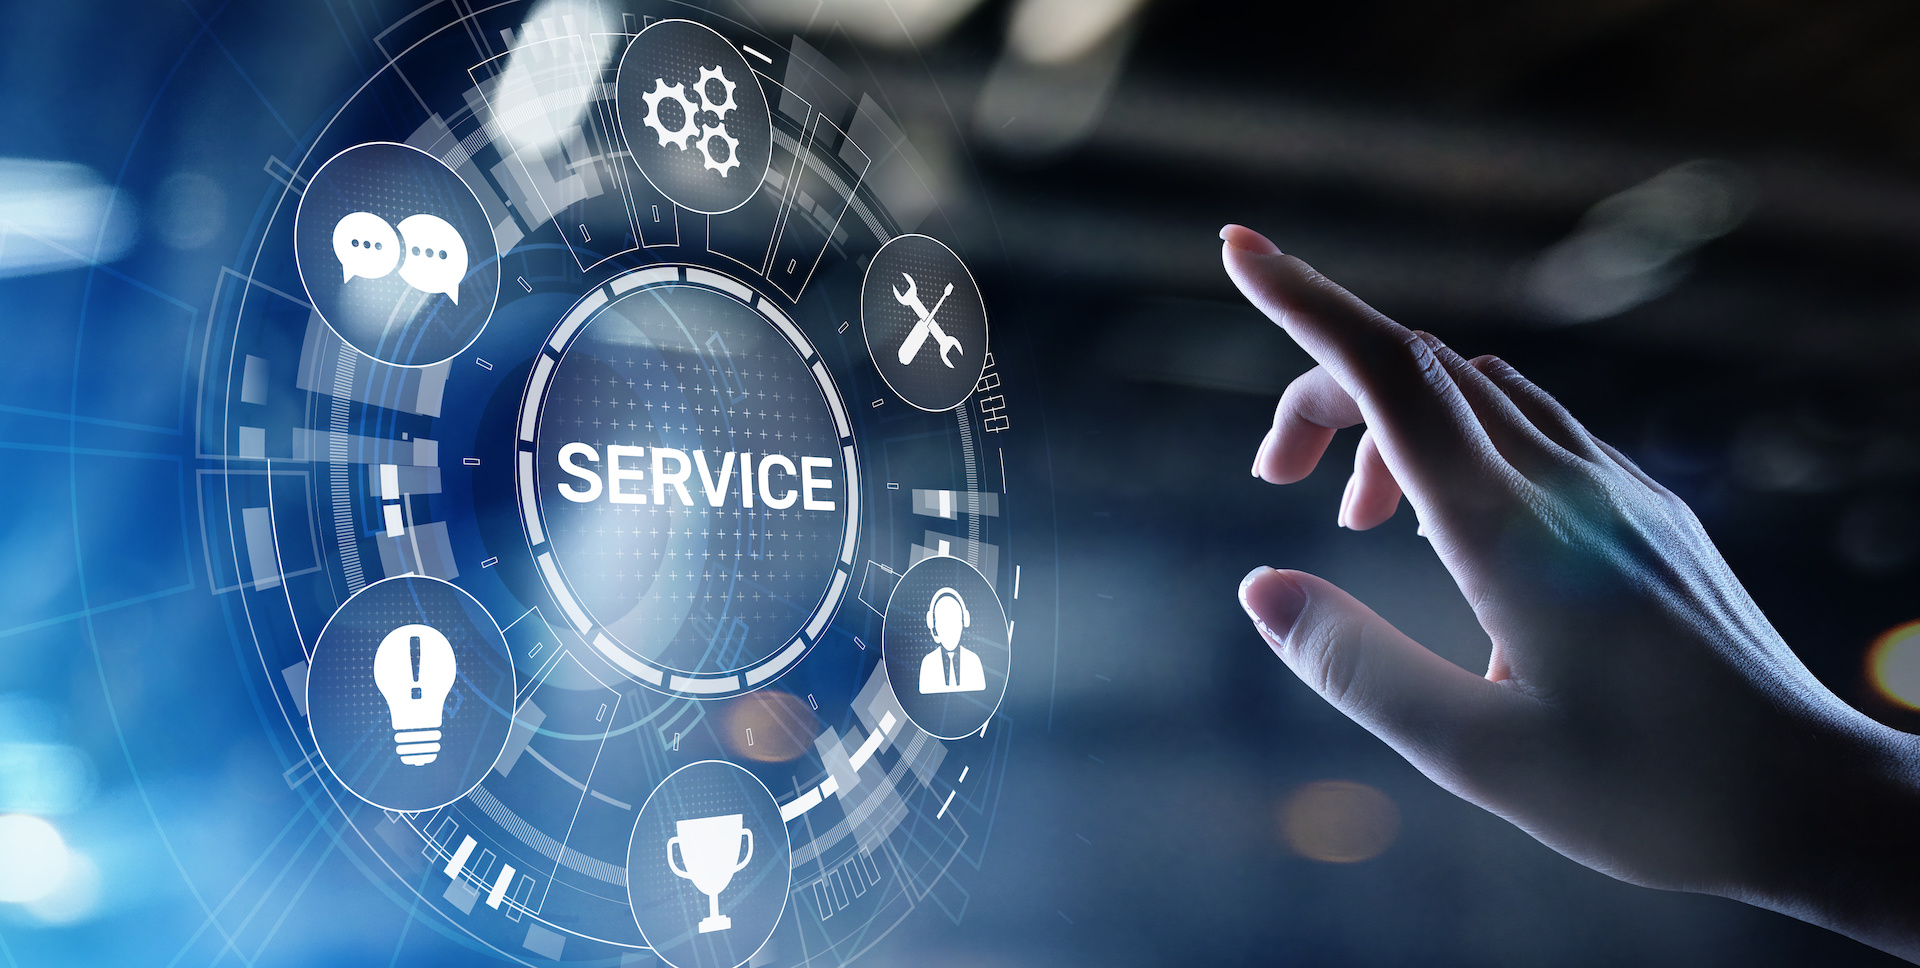

In [1]:
from IPython.display import Image
Image(filename='svr.jpeg')

--------------------------------
--------------------------------
--------------------------------

## **Import Libraries**


In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from datetime import datetime
import calendar
from scipy.stats import f_oneway

---------------------------------------
---------------------------------------
---------------------------------------

## **Exploratory Data Analysis (EDA)**

### **Initial Data Understanding**

 - **Data loading and Inspection**
 - **Data Types**
 - **Missing Values**
 - **Duplicates**

-------------------------

In [3]:
services_data = pd.read_csv('Services_data.csv')
branch_data = pd.read_csv('Branch_data.csv')

In [4]:
services_data.head()

,service_id,service_type_id,client_name,hours,service_date,service_time,hourly_rate,total_revenue,branch_id,department,service_description
0,1,6,Dunn-Joseph,10,7/6/2023,17:33:51,1200,12000,EM,Tax,Strategy Consulting
1,2,6,Grimes LLC,4,25/08/2023,6:59:24,900,3600,EA,Legal,Legal Consultation
2,3,5,"Ramirez, Rodriguez a",7,4/3/2023,16:42:55,900,6300,AP,Audit,Annual Tax Filing
3,4,4,"Vaughn, Wall and Woo",1,11/12/2023,3:46:30,1200,1200,AP,Tax,Annual Tax Filing
4,5,5,Harris PLC,2,20/08/2023,14:32:03,600,1200,AM,Management,Quarterly Review


In [5]:
branch_data.head()

,Branch ID,Country,Region
0,EA,Nigeria,EMEA
1,AP,China,APAC
2,AM,United States,Americas
3,EM,United Kingdom,Europe


In [6]:
services_data.shape

(48000, 11)

In [7]:
services_data.columns

Index(['service_id', 'service_type_id', 'client_name', 'hours', 'service_date',
       'service_time', 'hourly_rate', 'total_revenue', 'branch_id',
       'department', 'service_description'],
      dtype='object')

In [8]:
services_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   service_id           48000 non-null  int64 
 1   service_type_id      48000 non-null  int64 
 2   client_name          48000 non-null  object
 3   hours                48000 non-null  int64 
 4   service_date         48000 non-null  object
 5   service_time         48000 non-null  object
 6   hourly_rate          48000 non-null  int64 
 7   total_revenue        48000 non-null  int64 
 8   branch_id            48000 non-null  object
 9   department           48000 non-null  object
 10  service_description  48000 non-null  object
dtypes: int64(5), object(6)
memory usage: 4.0+ MB


In [9]:
services_data.isnull().sum()

service_id             0
service_type_id        0
client_name            0
hours                  0
service_date           0
service_time           0
hourly_rate            0
total_revenue          0
branch_id              0
department             0
service_description    0
dtype: int64

In [10]:
services_data.duplicated().sum()

np.int64(0)

-----------------------------------------

### **Basic Statistical Overview**
-------------------------------------------
- Summary Statistical : **describe()**

In [11]:
services_data.describe().T

,count,mean,std,min,25%,50%,75%,max
service_id,48000.0,24000.500000,13856.550797,1.0,12000.75,24000.5,36000.25,48000.0
service_type_id,48000.0,4.996958,2.580319,1.0,3.00,5.0,7.00,9.0
hours,48000.0,4.516292,2.305133,1.0,3.00,5.0,7.00,29.0
hourly_rate,48000.0,902.068750,423.615491,300.0,600.00,900.0,1200.00,1500.0
total_revenue,48000.0,4069.162500,2983.487387,300.0,1800.00,3600.0,6000.00,23400.0


In [12]:
services_data.select_dtypes(include='object').describe()

,client_name,service_date,service_time,branch_id,department,service_description
count,48000,48000,48000,48000,48000,48000
unique,4368,364,36796,4,5,5
top,Smith Inc,19/05/2023,2:25:47,EM,Legal,Annual Tax Filing
freq,90,163,5,17981,9682,9724


--------------------------------

- Summary Statistical : **value_counts()**

In [13]:
services_data.columns

Index(['service_id', 'service_type_id', 'client_name', 'hours', 'service_date',
       'service_time', 'hourly_rate', 'total_revenue', 'branch_id',
       'department', 'service_description'],
      dtype='object')

In [14]:
services_data['department'].value_counts().sort_values(ascending=False)

department
Legal         9682
Audit         9668
Management    9589
Advisory      9534
Tax           9527
Name: count, dtype: int64

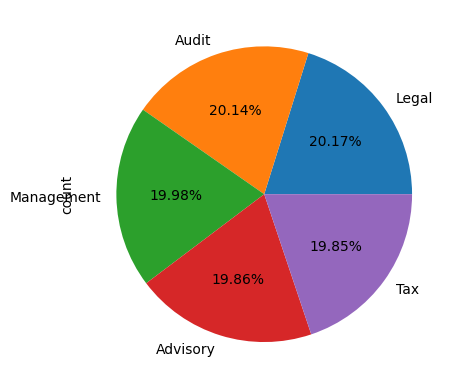

In [15]:
services_data['department'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

---------------------------------------
---------------------------------------

### **Distribution of Variables**
--------------------------
- **Numerical Features (KDE)**

In [16]:
services_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   service_id           48000 non-null  int64 
 1   service_type_id      48000 non-null  int64 
 2   client_name          48000 non-null  object
 3   hours                48000 non-null  int64 
 4   service_date         48000 non-null  object
 5   service_time         48000 non-null  object
 6   hourly_rate          48000 non-null  int64 
 7   total_revenue        48000 non-null  int64 
 8   branch_id            48000 non-null  object
 9   department           48000 non-null  object
 10  service_description  48000 non-null  object
dtypes: int64(5), object(6)
memory usage: 4.0+ MB


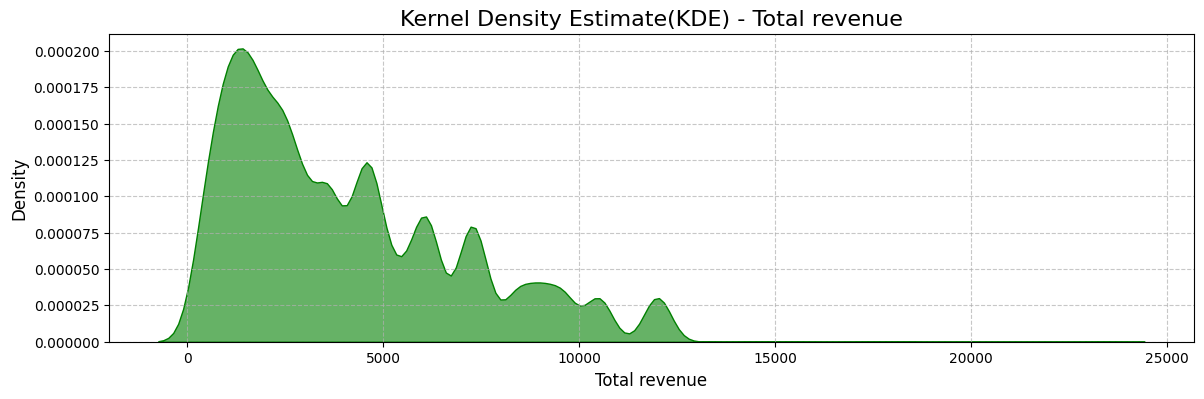

In [17]:
plt.figure(figsize=(14,	4))
sns.kdeplot(services_data['total_revenue'], fill=True,	color='green', alpha=0.6)
plt.title('Kernel Density Estimate(KDE) - Total revenue',	fontsize=16)
plt.xlabel('Total revenue',	fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

- ##### **Primary Concentration: The vast majority of transactions or revenue events cluster heavily near 0 (or slightly above), indicated by the highest and broadest peak.**

- ##### **Multimodal Nature: The presence of several distinct peaks (around 3,000-4,000, 5,500-6,000, and 7,000-8,000) suggests that the overall data is composed of several different groups or segments, each with its own characteristic average revenue level. This could represent different product tiers, customer types, or sales channels.**

- ##### **Skewness: The long tail to the right (positive values) indicates that while small revenues are most common, a few transactions or accounts generate significantly higher revenues.**

- ##### **Range: Meaningful revenue values appear to taper off around 13,000-15,000, with very few or no observations beyond this point. A small segment of the data also falls into negative values, potentially representing losses or net returns/refunds.**

-----------------------------
----------------------------

### **Checking Correlation between the features**

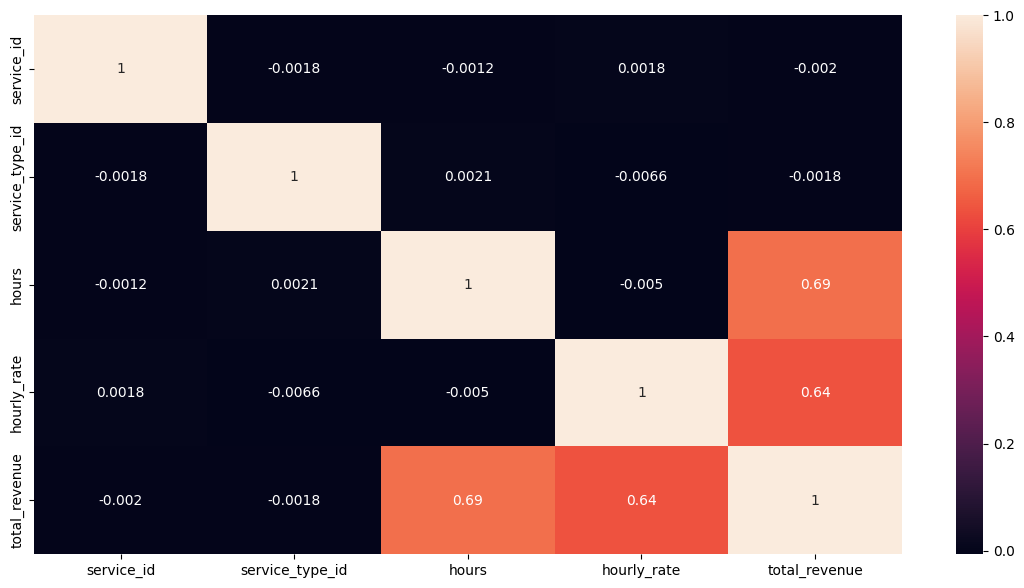

In [18]:
plt.figure(figsize=(14,	7))
sns.heatmap(services_data.select_dtypes(include='number').corr(), annot=True)
plt.show()

------------------------------

In [19]:
# plot scatter plot for high correlated columns
def scatter(df, x, y, title):
    plt.figure(figsize=(14, 4))
    ax = sns.scatterplot(x=x, y=y, data=df)
    ax.set_title(title)
    plt.show()

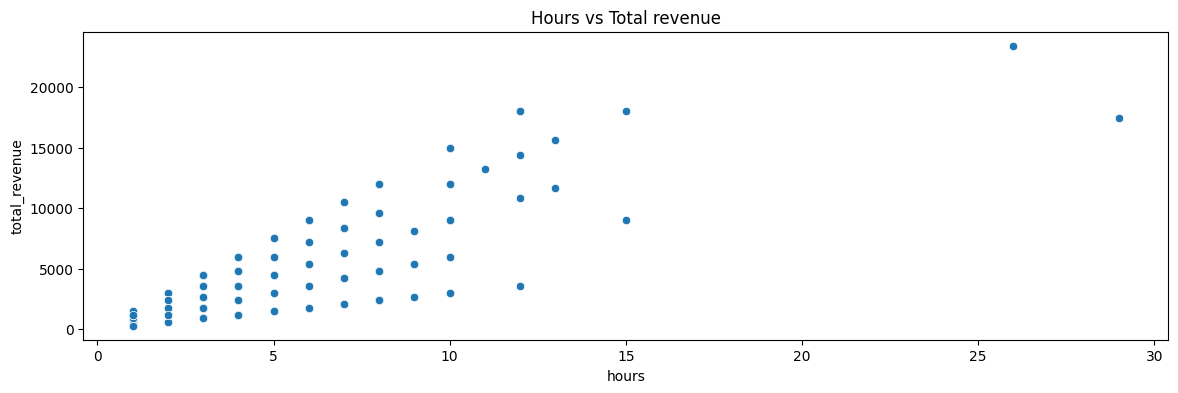

In [20]:
scatter(services_data, 'hours', 'total_revenue', 'Hours vs Total revenue')

- #### **Positive Correlation: There is a general positive trend, meaning that as the number of hours increases, the total revenue generated tends to increase as well.**

- #### **High Variability (Fan Shape): The data shows significant heteroscedasticity (non-constant variance), forming a noticeable fan shape.**

    - ##### **At low hours (e.g., 1-5), revenue is consistently low with a small spread (mostly below 5,000).**

    - ##### **As the hours increase (e.g., 8-15), the spread of revenue widens dramatically. This suggests that simply logging more hours is not the only factor; the quality or efficiency of those hours plays a major role in determining the final revenue outcome.**

- #### **Data Concentration: Most data points are concentrated in the range of 1 to 15 hours.**

- #### **High-Leverage Outliers: Two extreme data points exist far outside the main cluster, one near 26 hours (generating the highest revenue) and one near 29 hours. These represent rare instances of exceptionally long hours.**

---------------------------------
---------------------------------

## **Detect Outliers**

-------------------------

In [21]:
services_data['total_revenue'].describe()

count    48000.000000
mean      4069.162500
std       2983.487387
min        300.000000
25%       1800.000000
50%       3600.000000
75%       6000.000000
max      23400.000000
Name: total_revenue, dtype: float64

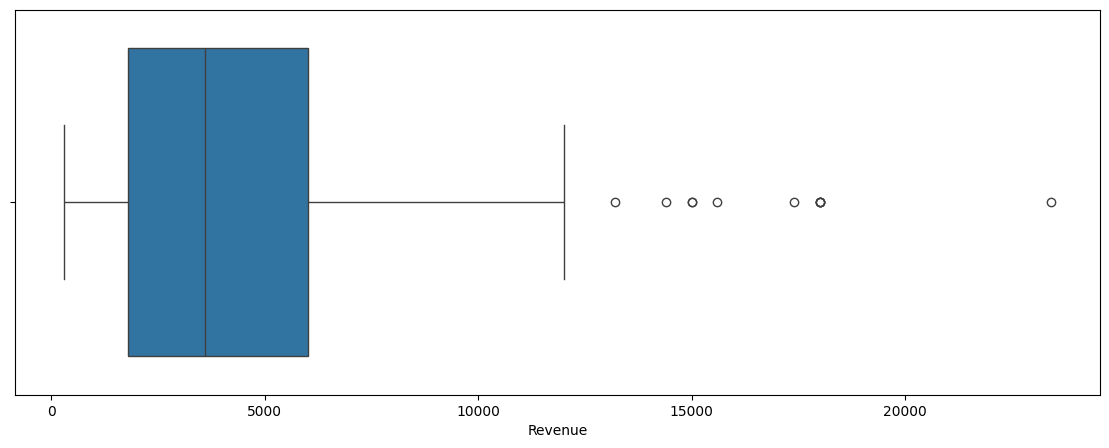

In [22]:
plt.fig, axes = plt.subplots(nrows=1,ncols=1)
plt.fig.set_size_inches(14, 5)
sns.boxplot(data=services_data,x="total_revenue",orient="o",ax=axes)
plt.xlabel('Revenue')
plt.show()

----------------------------

#### **Target Variable Analysis**
------------------------------

C:\Users\RPC\AppData\Local\Temp\ipykernel_2908\90074640.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=filtered_df['branch_id'], y=filtered_df['total_revenue'], palette="Set1")


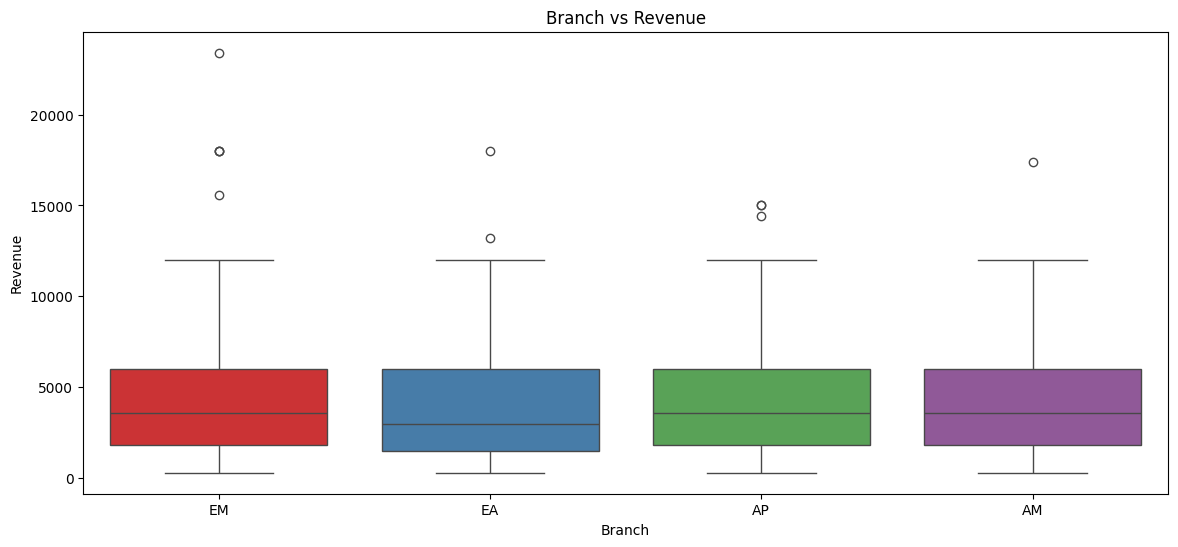

In [23]:
top_10_categs = services_data['branch_id'].value_counts().index[:10]
filtered_df = services_data[services_data['branch_id'].isin(top_10_categs)]

plt.figure(figsize=(14, 6))
sns.boxplot(x=filtered_df['branch_id'], y=filtered_df['total_revenue'], palette="Set1")
plt.title(f'Branch vs Revenue')
plt.xlabel('Branch')
plt.ylabel('Revenue')
plt.show()

C:\Users\RPC\AppData\Local\Temp\ipykernel_2908\1406125306.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=filtered_df['department'], y=filtered_df['total_revenue'], palette="Set2")


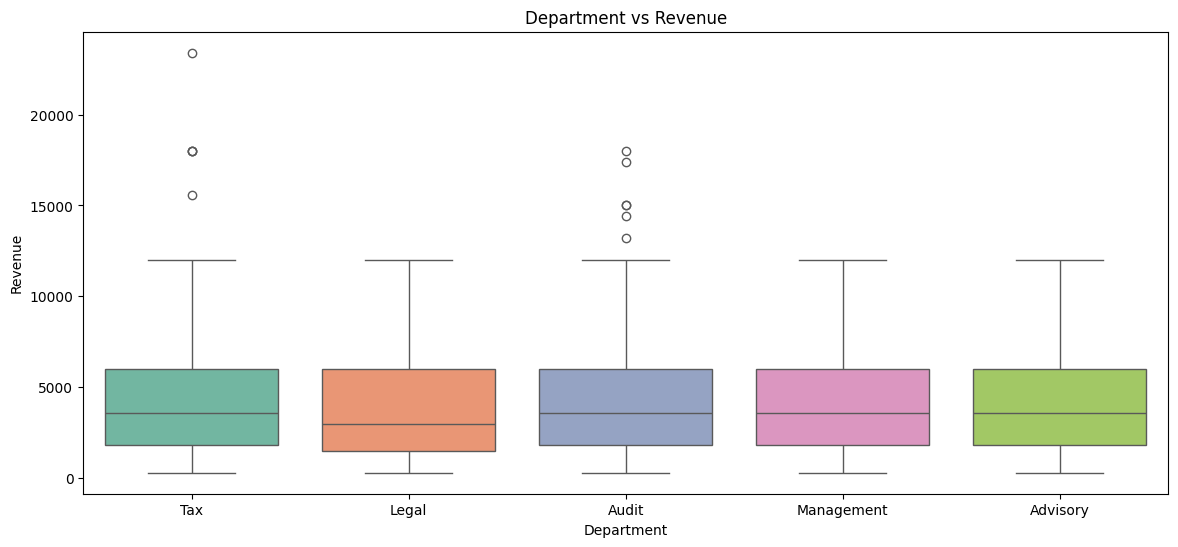

In [24]:
top_10_categs = services_data['department'].value_counts().index[:10]
filtered_df = services_data[services_data['department'].isin(top_10_categs)]

plt.figure(figsize=(14, 6))
sns.boxplot(x=filtered_df['department'], y=filtered_df['total_revenue'], palette="Set2")
plt.title(f'Department vs Revenue')
plt.xlabel('Department')
plt.ylabel('Revenue')
plt.show()

C:\Users\RPC\AppData\Local\Temp\ipykernel_2908\1329073264.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=filtered_df['service_description'], y=filtered_df['total_revenue'], palette="Set3")


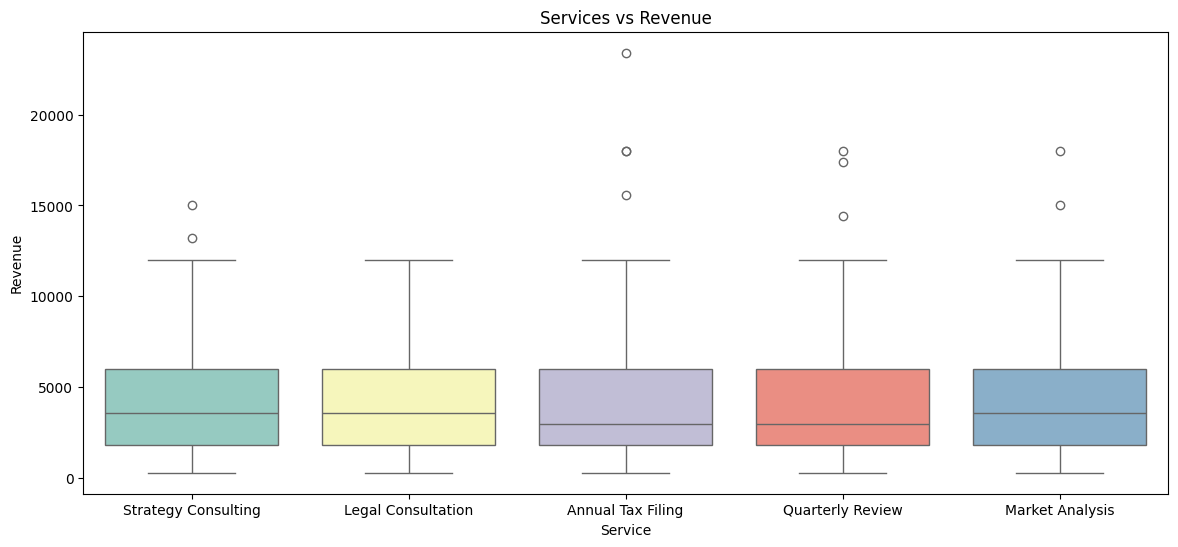

In [25]:
top_10_categs = services_data['service_description'].value_counts().index[:10]
filtered_df = services_data[services_data['service_description'].isin(top_10_categs)]

plt.figure(figsize=(14, 6))
sns.boxplot(x=filtered_df['service_description'], y=filtered_df['total_revenue'], palette="Set3")
plt.title(f'Services vs Revenue')
plt.xlabel('Service')
plt.ylabel('Revenue')
plt.show()

------------------------------------------
------------------------------------------

In [26]:
branch_data.columns

Index(['Branch ID', 'Country', 'Region'], dtype='object')

In [27]:
services_data.columns

Index(['service_id', 'service_type_id', 'client_name', 'hours', 'service_date',
       'service_time', 'hourly_rate', 'total_revenue', 'branch_id',
       'department', 'service_description'],
      dtype='object')

In [28]:
branch_data.rename(columns={'Branch ID': 'branch_id'}, inplace=True)

In [29]:
data = pd.merge(services_data, branch_data, how = 'outer', on='branch_id')

-------------------------------------
-------------------------------------
## **Feature Extraction**
-------------------------------------

In [30]:
def countplot(col_name, df):
    plt.fig,ax= plt.subplots()
    plt.fig.set_size_inches(12,5)    
    sns.countplot(x=col_name, data=df)
    plt.xlabel(col_name)
    plt.show()

In [31]:
def pei(data,col_name):
    data[col_name].value_counts().plot.pie(autopct='%0.2f%%')
    plt.show()

------------------------------

In [32]:
data['service_date']

0        20/08/2023
1        24/12/2023
2         3/10/2023
3        17/11/2023
4        21/10/2023
            ...    
47995    22/08/2023
47996    21/07/2023
47997      5/4/2023
47998      5/9/2023
47999     11/4/2023
Name: service_date, Length: 48000, dtype: object

In [33]:
data['Day_nbr'] = data['service_date'].apply(lambda x : x.split('/')[0])

In [34]:
def add0(a):
    a = str(a)
    if len(a) == 1:
        return '0'+ a
    else :
        return a
    
data['Day_nbr'] = data['Day_nbr'].apply(lambda x: add0(x))
data['Day_nbr']

0        20
1        24
2        03
3        17
4        21
         ..
47995    22
47996    21
47997    05
47998    05
47999    11
Name: Day_nbr, Length: 48000, dtype: object

In [35]:
data["Day_name"] = data['Day_nbr'].apply(lambda x : calendar.day_name[datetime.strptime(x,"%d").weekday()])

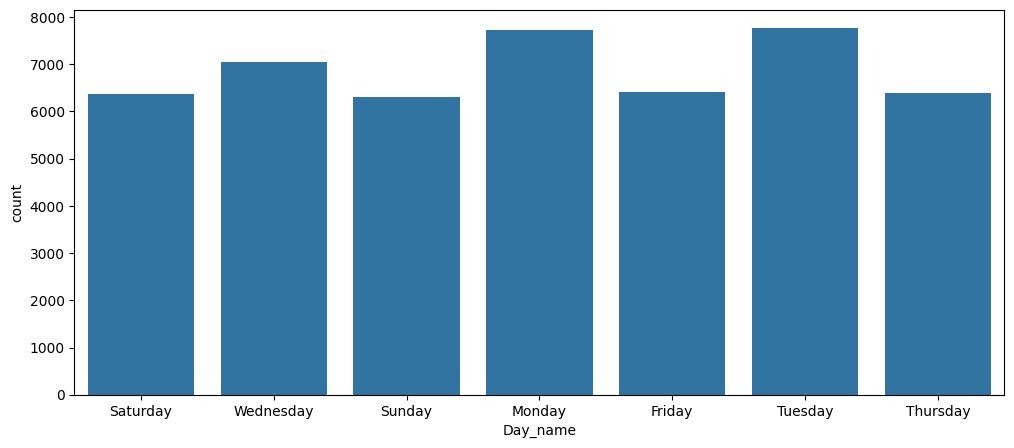

In [36]:
countplot('Day_name', data)

--------------------------------

In [37]:
def WeekEnd(day):
    day = str(day)
    if day == 'Saturday' or day == 'Sunday':
        return 'Weekend'
    else:
        return 'No'

data['weekend'] = data['Day_name'].apply(lambda x : WeekEnd(x))

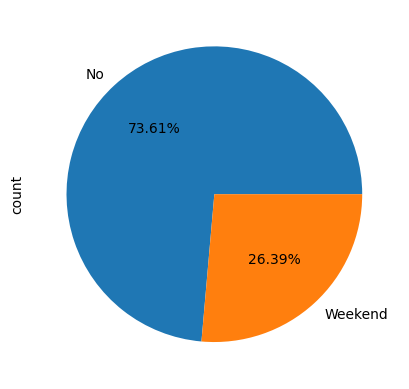

In [38]:
pei(data,'weekend')

---------------------------------

In [39]:
data['Day'] = data['Day_name'] + ' - '+data['Day_nbr']

In [40]:
data['Day']

0         Saturday - 20
1        Wednesday - 24
2        Wednesday - 03
3        Wednesday - 17
4           Sunday - 21
              ...      
47995       Monday - 22
47996       Sunday - 21
47997       Friday - 05
47998       Friday - 05
47999     Thursday - 11
Name: Day, Length: 48000, dtype: object

--------------------------

In [41]:
data['Month'] = data['service_date'].apply(lambda x : x.split('/')[1])

In [42]:
def add02(a):
    a = str(a)
    if len(a) == 1:
        return '0'+ a
    else :
        return a
    
data['Month'] = data['Month'].apply(lambda x: add02(x))

In [43]:
data['Month'].value_counts()

Month
03    4226
07    4139
10    4118
08    4080
11    4065
04    4014
05    4012
09    3983
01    3930
12    3872
06    3859
02    3702
Name: count, dtype: int64

In [44]:
data["Month"] = data['Month'].apply(lambda x : calendar.month_name[datetime.strptime(x,"%m").month])

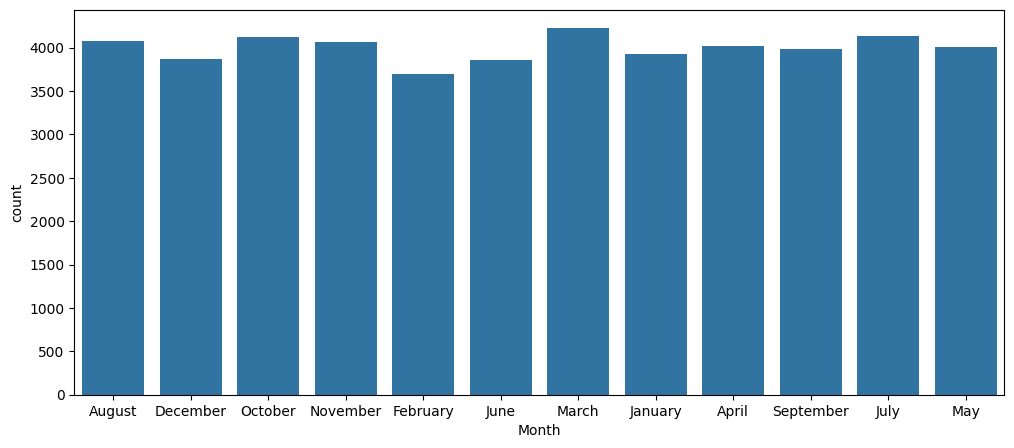

In [45]:
countplot('Month',data)

-------------------------------

In [46]:
data['Year'] = data['service_date'].apply(lambda x : x.split('/')[2])

In [47]:
data['Year'].value_counts()

Year
2023    48000
Name: count, dtype: int64

-------------------------------

In [48]:
data['Hour'] = data['service_time'].apply(lambda x : x.split(':')[0])

In [49]:
data['Hour'] = data['Hour'].astype(int)

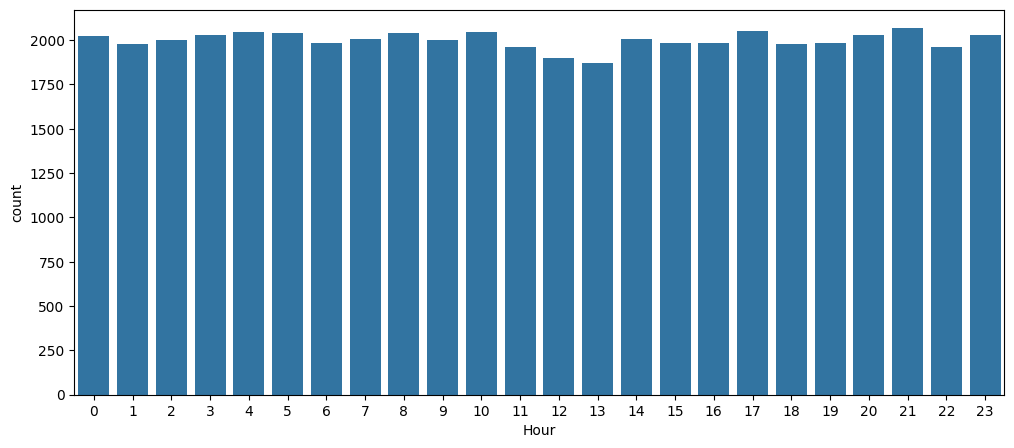

In [50]:
countplot('Hour',data)

-------------------------------------------

In [51]:
def PeriodsPerDay(hour):
    hour = int(hour)
    if 6 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 13:
        return 'Midday/Noon'
    elif 14 <= hour <= 17:
        return 'Afternoon'
    elif 18 <= hour <= 20:
        return 'Evening'
    elif 21 <= hour <= 23:
        return 'Night'
    else: # 0 <= hour <= 5
        return 'Midnight and After'

data['Periods per day'] = data['Hour'].apply(lambda x : PeriodsPerDay(x))

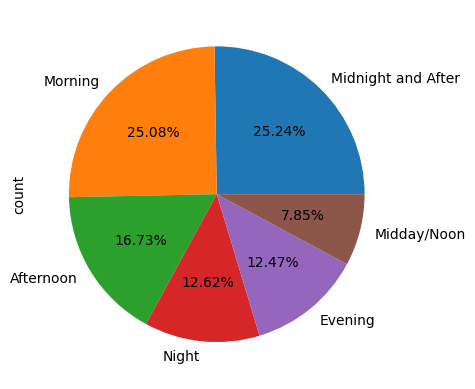

In [52]:
pei(data, 'Periods per day')

--------------------------------

In [53]:
data['Month'].value_counts()

Month
March        4226
July         4139
October      4118
August       4080
November     4065
April        4014
May          4012
September    3983
January      3930
December     3872
June         3859
February     3702
Name: count, dtype: int64

In [54]:
def get_season(month):
    if month in ['December', 'January', 'February']:
        return 'Winter'   
    elif month in ['March', 'April', 'May']:
        return 'Spring'   
    elif month in ['June', 'July', 'August']:
        return 'Summer'   
    else:
        return 'Autumn'   

data['Season'] = data['Month'].apply(get_season)

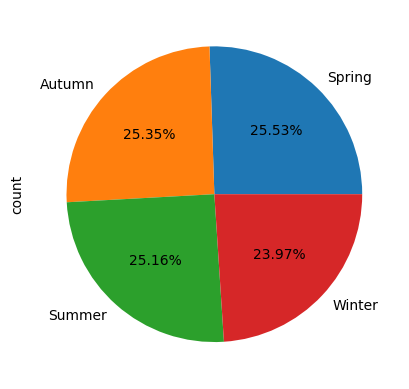

In [55]:
pei(data,'Season')

-----------------------------

In [56]:
def rev(a):
    if a < 1500.8:
        return 'Low'
    elif a < 3000.2:
        return 'Medium'
    else:
        return 'High'

data['Revenue_Level'] = data['total_revenue'].apply(lambda x : rev(x))

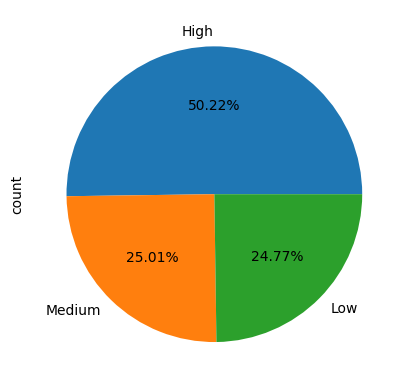

In [57]:
pei(data,'Revenue_Level')

-----------------------------

In [58]:
def week(a):
    if a in ['01','02','03','04','05','06','07']:
        return 'Week 1' 
    elif a in ['08','09','10','11','12','13','14']:
        return 'Week 2'
    elif a in ['15','16','17','18','19','20','21']:
        return 'Week 3'
    else :
        return 'Week 4'

data['Weeks'] = data['Day_nbr'].apply(lambda x : week(x))    

In [59]:
data['Weeks'].value_counts()

Weeks
Week 4    14682
Week 3    11146
Week 1    11105
Week 2    11067
Name: count, dtype: int64

In [60]:
#data.to_csv('services analysis (new dataset).csv',index=False)

----------------------------
----------------------------

## **Statistical Analysis**

------------------------------

In [61]:
df = data.copy()

In [62]:
# hours * hourly = total_revenue
df[['hours','hourly_rate','total_revenue']].describe()

,hours,hourly_rate,total_revenue
count,48000.000000,48000.000000,48000.000000
mean,4.516292,902.068750,4069.162500
std,2.305133,423.615491,2983.487387
min,1.000000,300.000000,300.000000
25%,3.000000,600.000000,1800.000000
50%,5.000000,900.000000,3600.000000
75%,7.000000,1200.000000,6000.000000
max,29.000000,1500.000000,23400.000000


In [63]:
df.groupby('branch_id')['department'].nunique()

branch_id
AM    5
AP    5
EA    5
EM    5
Name: department, dtype: int64

In [64]:
df.groupby('branch_id')['department'].unique()

branch_id
AM    [Management, Tax, Audit, Legal, Advisory]
AP    [Audit, Tax, Management, Legal, Advisory]
EA    [Legal, Advisory, Audit, Tax, Management]
EM    [Tax, Advisory, Management, Legal, Audit]
Name: department, dtype: object

In [65]:
df.groupby(['branch_id', 'department'])['service_description'].unique().reset_index()

,branch_id,department,service_description
0,AM,Advisory,"[Legal Consultation, Market Analysis, Annual T..."
1,AM,Audit,"[Annual Tax Filing, Strategy Consulting, Legal..."
2,AM,Legal,"[Legal Consultation, Market Analysis, Strategy..."
3,AM,Management,"[Quarterly Review, Market Analysis, Legal Cons..."
4,AM,Tax,"[Annual Tax Filing, Strategy Consulting, Quart..."
5,AP,Advisory,"[Quarterly Review, Annual Tax Filing, Strategy..."
6,AP,Audit,"[Annual Tax Filing, Legal Consultation, Strate..."
7,AP,Legal,"[Quarterly Review, Strategy Consulting, Market..."
8,AP,Management,"[Legal Consultation, Strategy Consulting, Quar..."
9,AP,Tax,"[Annual Tax Filing, Legal Consultation, Strate..."


-----------------------------
### ***Revenue for each season***
---------------------

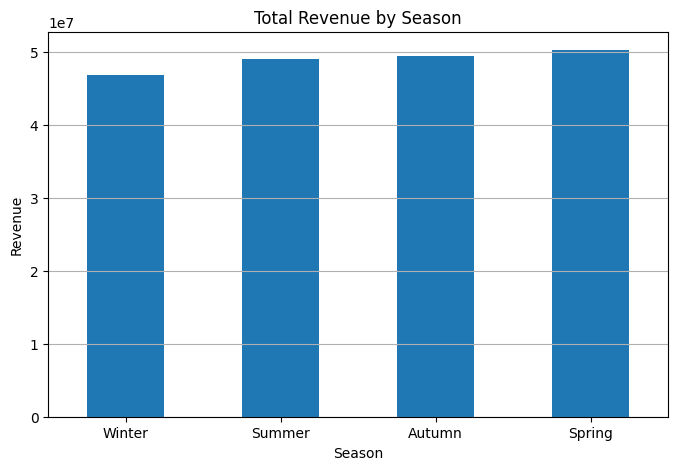

In [109]:
import matplotlib.pyplot as plt

season_rev = df.groupby('Season')['total_revenue'].sum().sort_values()

plt.figure(figsize=(8,5))
season_rev.plot(kind='bar')
plt.title('Total Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


##### **The Spring season generated the highest total revenue**

------------------------------
### ***Revenue by Department Across Seasons***
-----------------------------

<Figure size 1000x600 with 0 Axes>

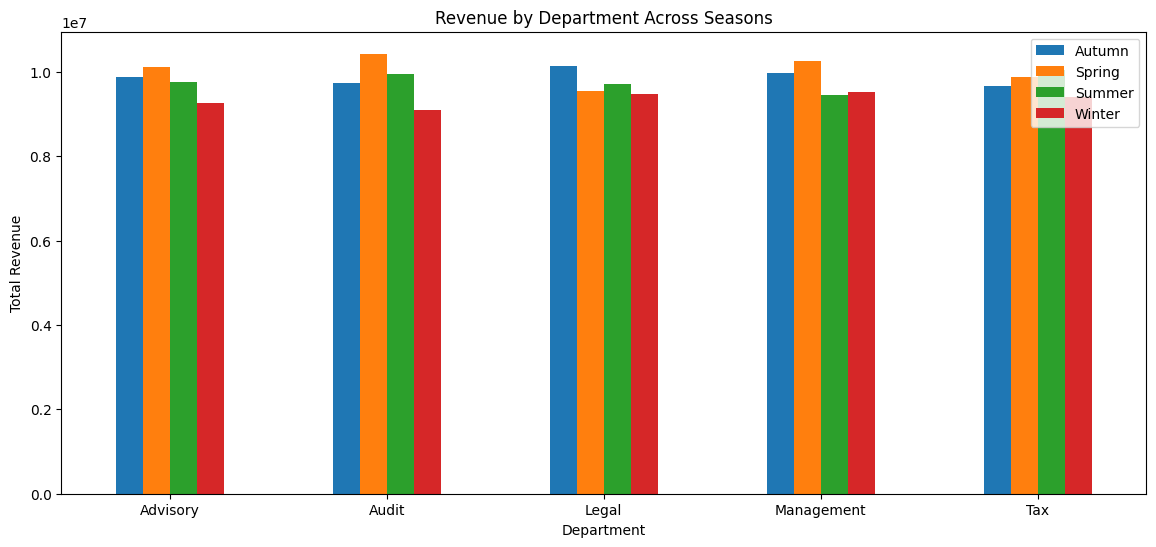

In [114]:
season_dept = df.groupby(['Season', 'department'])['total_revenue'].sum().reset_index()

pivot_sd = season_dept.pivot(index='department', columns='Season', values='total_revenue')

plt.figure(figsize=(10,6))
pivot_sd.plot(kind='bar', figsize=(14,6))
plt.title('Revenue by Department Across Seasons')
plt.ylabel('Total Revenue')
plt.xlabel('Department')
plt.xticks(rotation=0)
plt.legend()
plt.show()

- ##### **The department with the highest total revenue across all seasons is either Management or Audit, as the sum of their four seasonal bars appears to be the greatest.**

- ##### **Both Management and Audit reach the highest single-season revenue mark, which is the Spring season, with revenue slightly over $100** million.

- ##### **The Winter season generally shows the lowest revenue for most departments.**

----------------------------
### ***Seasonal analysis by Country***
----------------------------

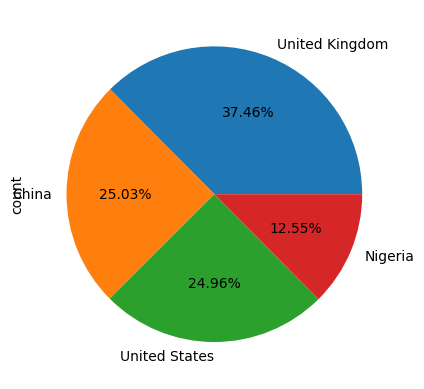

In [66]:
pei(df, 'Country')

In [67]:
country_revenue_sum = df.groupby('Country')['total_revenue'].sum().sort_values(ascending=False)
country_revenue_sum

Country
United Kingdom    73691700
United States     48765000
China             48759000
Nigeria           24104100
Name: total_revenue, dtype: int64

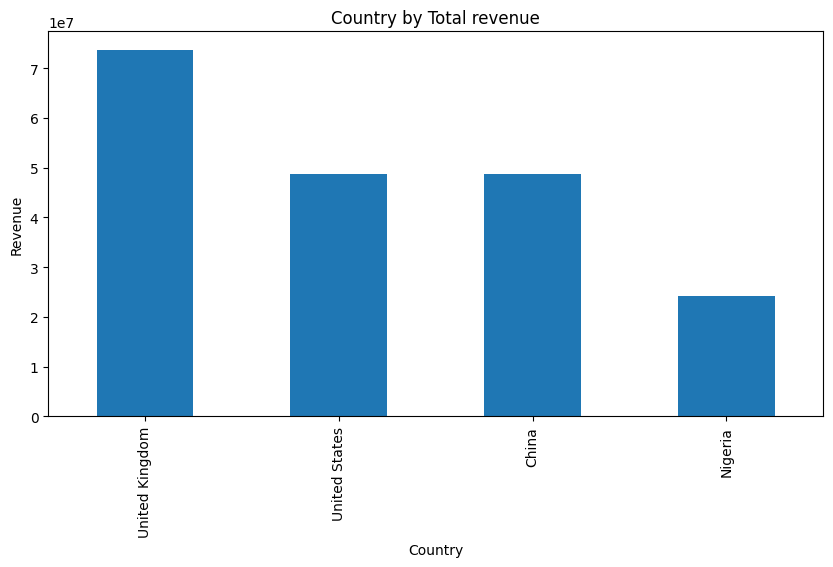

In [68]:
plt.fig,ax= plt.subplots()
plt.fig.set_size_inches(10,5) 
country_revenue_sum.plot(kind='bar')
plt.title("Country by Total revenue")
plt.xlabel('Country')
plt.ylabel("Revenue")
plt.show()

- ##### **United kingdom has a highest total revenue**
- ##### **Nigeria has a lowest total revenue**

In [116]:
season_country = df.groupby(['Country', 'Season'])['total_revenue'].sum().reset_index()
season_country

,Country,Season,total_revenue
0,China,Autumn,12151800
1,China,Spring,12415500
2,China,Summer,12281400
3,China,Winter,11910300
4,Nigeria,Autumn,6083400
5,Nigeria,Spring,6653700
6,Nigeria,Summer,5825100
7,Nigeria,Winter,5541900
8,United Kingdom,Autumn,18677700
9,United Kingdom,Spring,18639000


In [118]:
pivot_sc = season_country.pivot(index='Country', columns='Season', values='total_revenue')
pivot_sc

Season,Autumn,Spring,Summer,Winter
Country,,,,
China,12151800,12415500,12281400,11910300
Nigeria,6083400,6653700,5825100,5541900
United Kingdom,18677700,18639000,18821100,17553900
United States,12504300,12494700,12001200,11764800


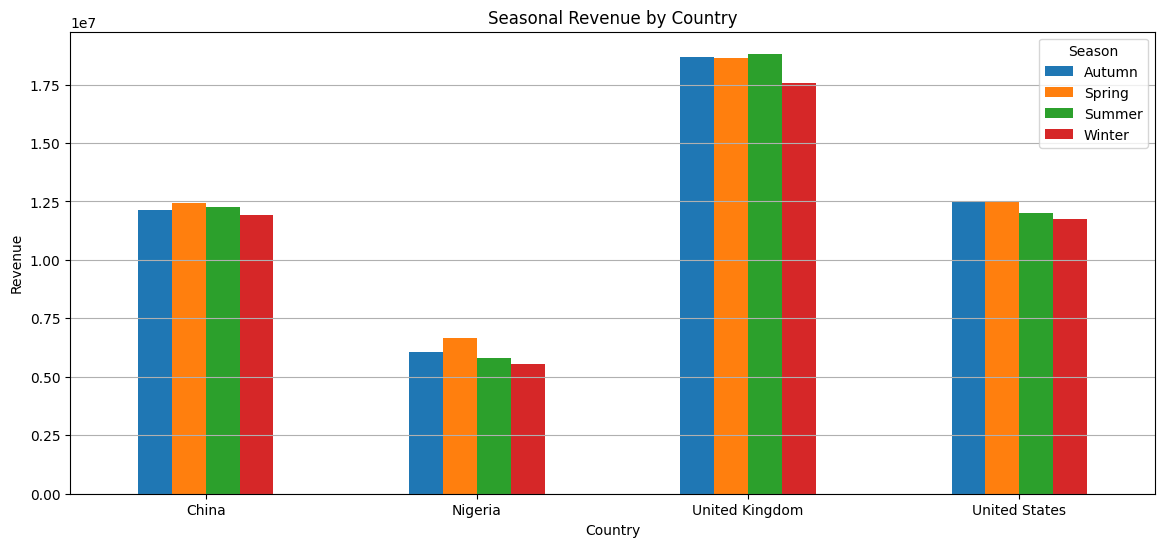

In [121]:
pivot_sc.plot(kind='bar', figsize=(14,6))
plt.title('Seasonal Revenue by Country')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


- ##### **China and the United States generated similar total revenue, significantly higher than Nigeria but lower than the UK.**

- ##### **For China, the Spring season was the highest performer, with revenue of about $12.25 million.**

- ##### **For the United States, the Autumn season was the highest performer, with revenue of about $12.5 million.**

------------------------------------
### ***Seasonal analysis by Region***
-----------------------------------

In [122]:
season_region = df.groupby(['Region', 'Season'])['total_revenue'].sum().reset_index()
season_region

,Region,Season,total_revenue
0,APAC,Autumn,12151800
1,APAC,Spring,12415500
2,APAC,Summer,12281400
3,APAC,Winter,11910300
4,Americas,Autumn,12504300
5,Americas,Spring,12494700
6,Americas,Summer,12001200
7,Americas,Winter,11764800
8,EMEA,Autumn,6083400
9,EMEA,Spring,6653700


In [123]:
pivot_sr = season_region.pivot(index='Region', columns='Season', values='total_revenue')
pivot_sr


Season,Autumn,Spring,Summer,Winter
Region,,,,
APAC,12151800,12415500,12281400,11910300
Americas,12504300,12494700,12001200,11764800
EMEA,6083400,6653700,5825100,5541900
Europe,18677700,18639000,18821100,17553900


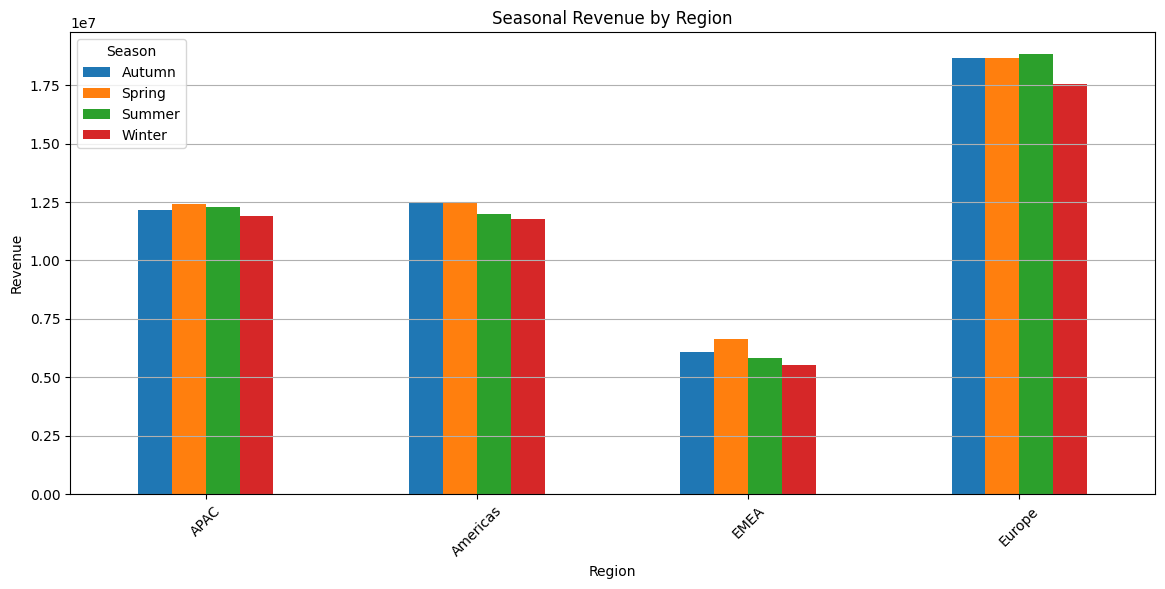

In [124]:
pivot_sr.plot(kind='bar', figsize=(14,6))
plt.title('Seasonal Revenue by Region')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

- ##### **APAC (Asia-Pacific) and Americas generated very similar total revenues, both significantly higher than EMEA but far below Europe.**

- ##### **For both APAC and Americas, the Spring season was the highest performer, with revenue just over $12.5 million.**

- ##### **All three regions (APAC, Americas, and EMEA) showed the Winter season as their lowest-performing season.**

------------------------------
### ***Renenue analysis by services***
-----------------------------
- ##### **Value counts for each service**
-----------------------------

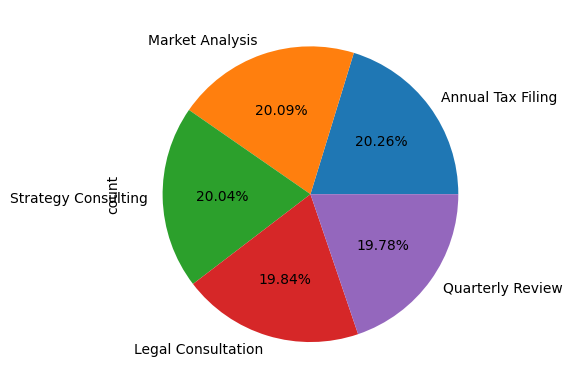

In [69]:
pei(df, 'service_description')

---------------------------------
- ##### **Total revenue for each service**
--------------------------------

In [70]:
service_rev_sum = df.groupby('service_description')['total_revenue'].sum().sort_values(ascending=False)
service_rev_sum

service_description
Annual Tax Filing      39516000
Strategy Consulting    39316200
Legal Consultation     39048000
Market Analysis        38952900
Quarterly Review       38486700
Name: total_revenue, dtype: int64

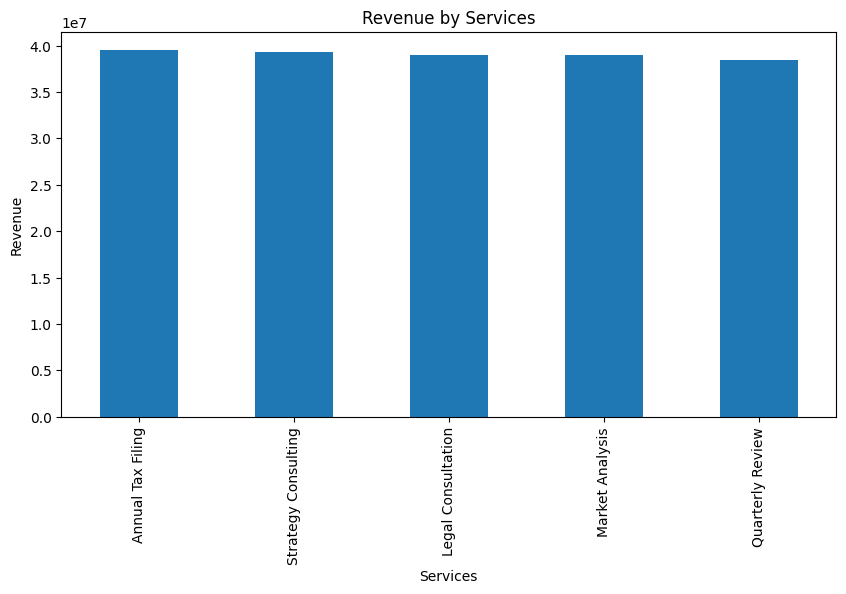

In [71]:
plt.fig,ax= plt.subplots()
plt.fig.set_size_inches(10,5) 
service_rev_sum.plot(kind='bar')
plt.title("Revenue by Services")
plt.xlabel('Services')
plt.ylabel("Revenue")
plt.show()

- ##### **Annual tax filling service has a highest sum revenue**
- ##### **Quarterly review service has a lowest sum revenue**
#### **The values of sum revenue ​​are almost similar**

-----------------------
- ##### **Total revenue of services for each region**
-------------------------

In [72]:
service_region_sum = df.groupby(['service_description','Region'])['total_revenue'].sum().reset_index()
service_region_sum

,service_description,Region,total_revenue
0,Annual Tax Filing,APAC,10254300
1,Annual Tax Filing,Americas,9803400
2,Annual Tax Filing,EMEA,4770000
3,Annual Tax Filing,Europe,14688300
4,Legal Consultation,APAC,9579300
5,Legal Consultation,Americas,9777600
6,Legal Consultation,EMEA,5027100
7,Legal Consultation,Europe,14664000
8,Market Analysis,APAC,9945900
9,Market Analysis,Americas,9452100


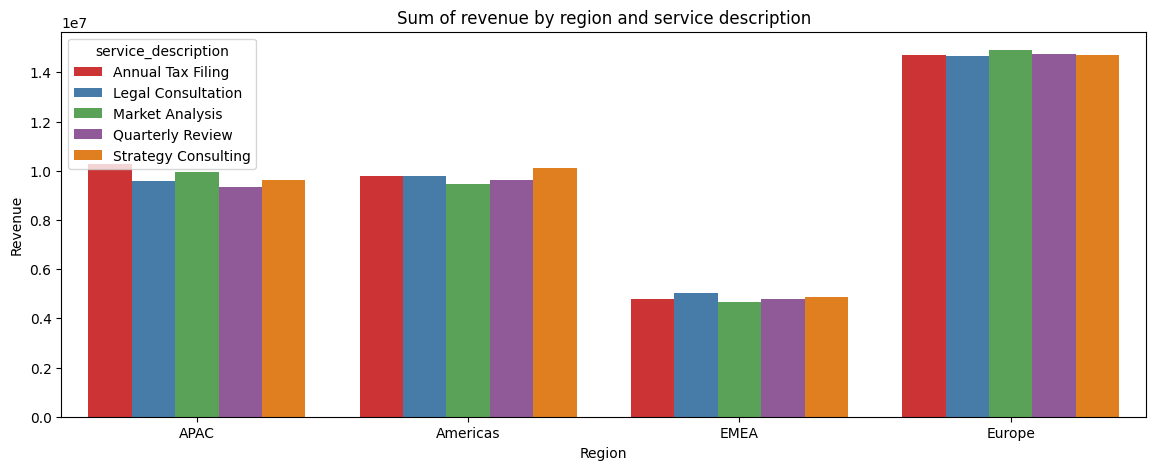

In [73]:
plt.figure(figsize=(14, 5))
ax = sns.barplot(x='Region', y='total_revenue', hue='service_description', data=service_region_sum, palette='Set1')
plt.title('Sum of revenue by region and service description')
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.show()

- ##### **Europe:** By far the highest-performing region, with all five services generating revenue well over $14 million each, nearly reaching $15 million. This region accounts for the largest share of the total revenue.

- ##### **APAC (Asia-Pacific) and Americas:** These regions show moderate to high revenue, clustering just under $10 million for most services. The performance is similar between the two regions, though the Americas shows slightly higher revenue for "Strategy Consulting."

- ##### **EMEA (Europe, Middle East, and Africa):** This is the lowest-performing region by a large margin. Revenue for all services is significantly lower, falling just under $5 million each.

-------------------------
- ##### **Total revenue of services for each month**
-------------------------

In [74]:
monthAggregated = pd.DataFrame(df.groupby(["service_description","Month"], sort=True)['total_revenue'].sum()).reset_index()
monthAggregated

,service_description,Month,total_revenue
0,Annual Tax Filing,April,3394500
1,Annual Tax Filing,August,3374100
2,Annual Tax Filing,December,3354000
3,Annual Tax Filing,February,2839800
4,Annual Tax Filing,January,3004500
5,Annual Tax Filing,July,3687300
6,Annual Tax Filing,June,3297300
7,Annual Tax Filing,March,3560700
8,Annual Tax Filing,May,3201900
9,Annual Tax Filing,November,3131100


C:\Users\RPC\AppData\Local\Temp\ipykernel_2908\761482759.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=monthAggregated["Month"], y=monthAggregated["total_revenue"],hue=monthAggregated["service_description"], data=monthAggregated, join=True,ax=ax)


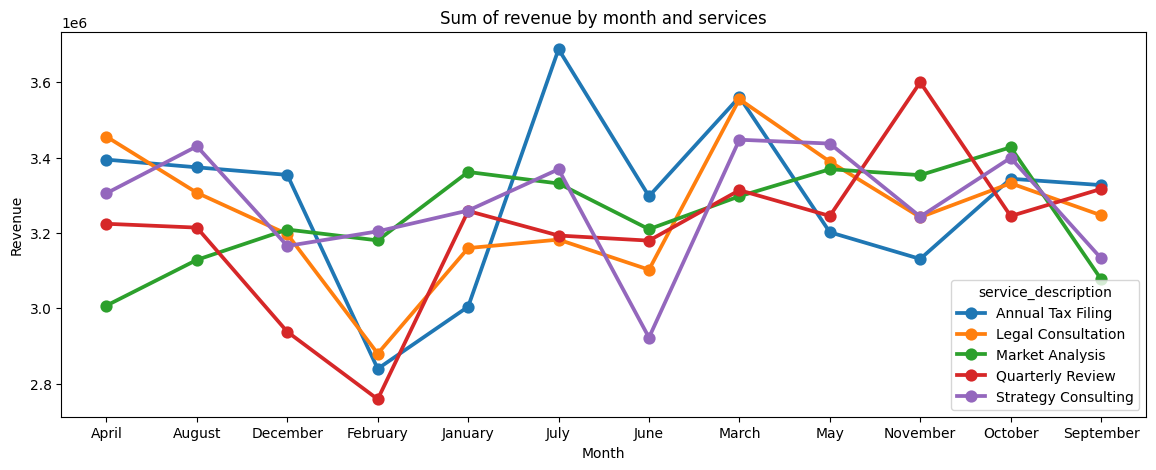

In [75]:
fig,ax= plt.subplots()
fig.set_size_inches(14,5)
sns.pointplot(x=monthAggregated["Month"], y=monthAggregated["total_revenue"],hue=monthAggregated["service_description"], data=monthAggregated, join=True,ax=ax)
ax.set(xlabel='Month', ylabel='Revenue',title="Sum of revenue by month and services",label='big')
plt.show()

----------------------------
- ##### **Total revenue of services for each day**
----------------------------

In [76]:
DayAggregated = pd.DataFrame(df.groupby(["service_description","Day_name"], sort=True)['total_revenue'].sum()).reset_index()
DayAggregated

,service_description,Day_name,total_revenue
0,Annual Tax Filing,Friday,5351100
1,Annual Tax Filing,Monday,6459000
2,Annual Tax Filing,Saturday,5165400
3,Annual Tax Filing,Sunday,5259900
4,Annual Tax Filing,Thursday,5026800
5,Annual Tax Filing,Tuesday,6290100
6,Annual Tax Filing,Wednesday,5963700
7,Legal Consultation,Friday,5226900
8,Legal Consultation,Monday,6484200
9,Legal Consultation,Saturday,5394600


C:\Users\RPC\AppData\Local\Temp\ipykernel_2908\1522587006.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=DayAggregated["Day_name"], y=DayAggregated["total_revenue"],hue=DayAggregated["service_description"], data=DayAggregated, join=True,ax=ax)


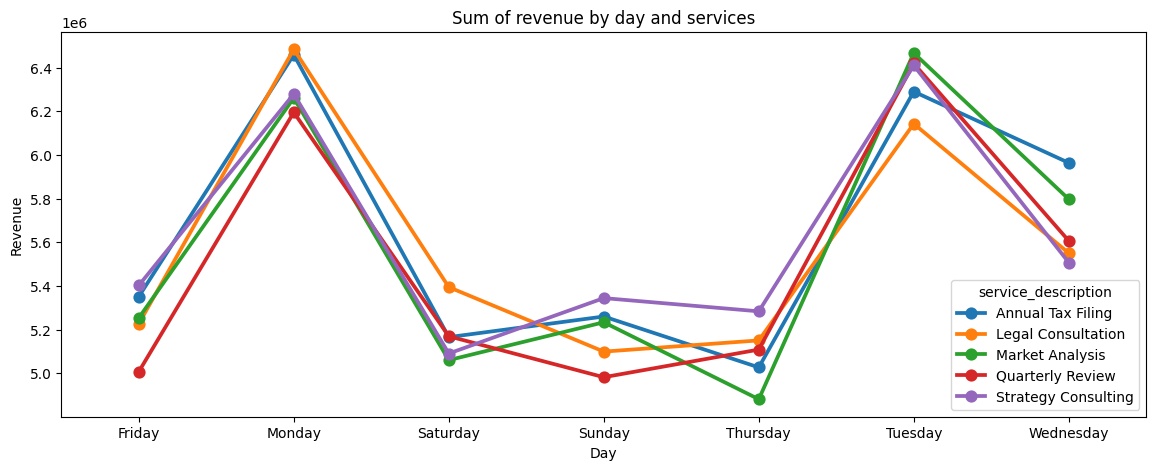

In [77]:
fig,ax= plt.subplots()
fig.set_size_inches(14,5)
sns.pointplot(x=DayAggregated["Day_name"], y=DayAggregated["total_revenue"],hue=DayAggregated["service_description"], data=DayAggregated, join=True,ax=ax)
ax.set(xlabel='Day', ylabel='Revenue',title="Sum of revenue by day and services",label='big')
plt.show()

----------------------------
- ##### **Total revenue of services for each period of day**
----------------------------

In [78]:
PeriodsPerDayAggregated = pd.DataFrame(df.groupby(["service_description","Periods per day"], sort=True)['total_revenue'].sum()).reset_index()
PeriodsPerDayAggregated

,service_description,Periods per day,total_revenue
0,Annual Tax Filing,Afternoon,6628200
1,Annual Tax Filing,Evening,4965300
2,Annual Tax Filing,Midday/Noon,3221100
3,Annual Tax Filing,Midnight and After,9842400
4,Annual Tax Filing,Morning,9954600
5,Annual Tax Filing,Night,4904400
6,Legal Consultation,Afternoon,6563700
7,Legal Consultation,Evening,4974600
8,Legal Consultation,Midday/Noon,3205800
9,Legal Consultation,Midnight and After,9640500


C:\Users\RPC\AppData\Local\Temp\ipykernel_2908\221832628.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=PeriodsPerDayAggregated["Periods per day"], y=PeriodsPerDayAggregated["total_revenue"],hue=PeriodsPerDayAggregated["service_description"], data=PeriodsPerDayAggregated, join=True,ax=ax)


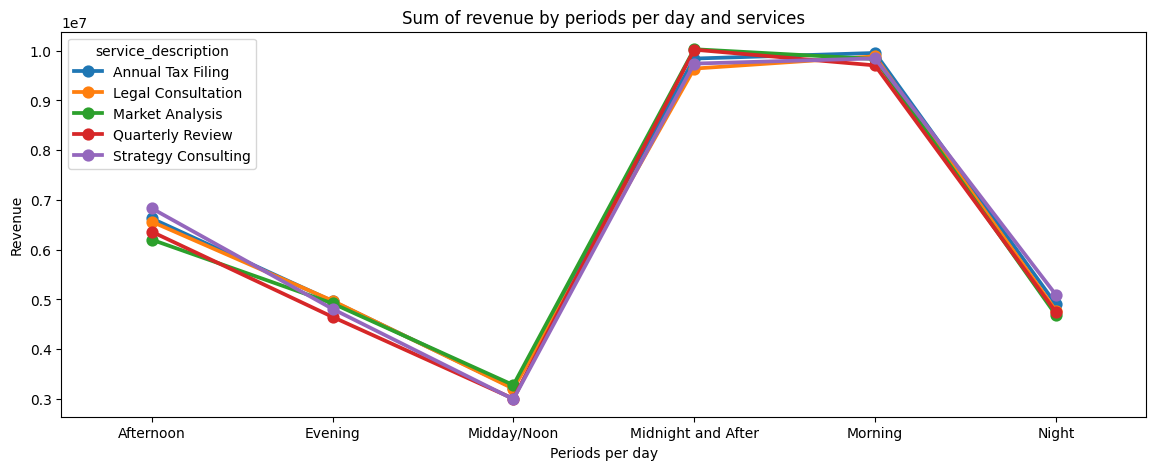

In [79]:
fig,ax= plt.subplots()
fig.set_size_inches(14,5)
sns.pointplot(x=PeriodsPerDayAggregated["Periods per day"], y=PeriodsPerDayAggregated["total_revenue"],hue=PeriodsPerDayAggregated["service_description"], data=PeriodsPerDayAggregated, join=True,ax=ax)
ax.set(xlabel='Periods per day', ylabel='Revenue',title="Sum of revenue by periods per day and services",label='big')
plt.show()

##### **Consistency : All five services track each other extremely closely. The relative performance order rarely changes, and their revenue lines are almost perfectly overlaid, especially during the peak and trough periods. This suggests that the time of day is the overwhelming factor influencing revenue, not the specific service.**

##### **Slight Lead in Peaks:**

-   ##### **Afternoon: Strategy Consulting is slightly ahead.**

-   ##### **Midnight and After: Market Analysis is slightly ahead, being the only one to reach exactly $100 million.**

##### **Lowest Revenue: The lowest single point for any service appears to be Market Analysis or Annual Tax Filing during Midday/Noon, around $30 million.**

------------------------------------
### ***Revenue analysis by branches***
------------------------------------
- ##### **Value counts for each branch**
------------------------------------

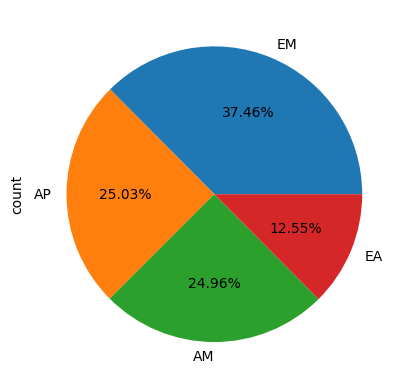

In [80]:
pei(df,'branch_id')

------------------------------------
- ##### **Total revenue for each branch**
------------------------------------

In [81]:
branch_rev_sum = df.groupby('branch_id')['total_revenue'].sum().sort_values(ascending=False)
branch_rev_sum

branch_id
EM    73691700
AM    48765000
AP    48759000
EA    24104100
Name: total_revenue, dtype: int64

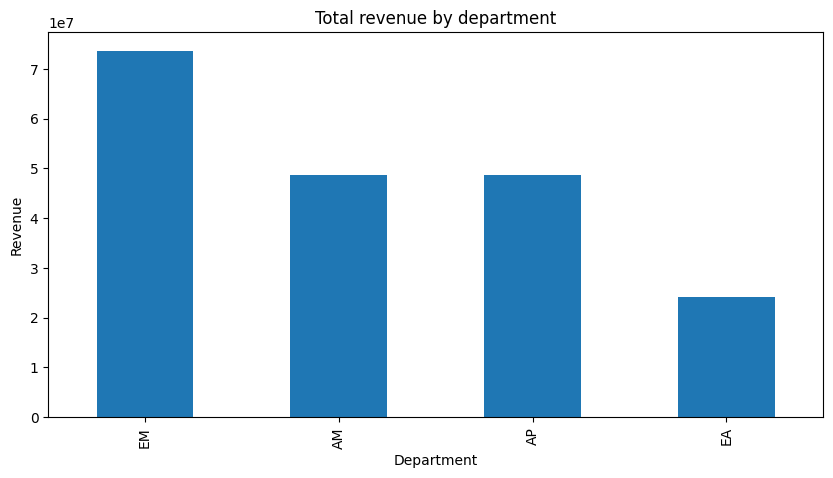

In [82]:
plt.fig,ax= plt.subplots()
plt.fig.set_size_inches(10,5) 
branch_rev_sum.plot(kind='bar')
plt.title("Total revenue by department")
plt.xlabel('Department')
plt.ylabel("Revenue")
plt.show()

- ##### **EM (Highest Revenue):** This department is the top revenue generator, with a total revenue of approximately $73 million.

- ##### **AM and AP (Middle Revenue):** These two departments generate nearly an identical amount of revenue, both around $49 million. They are the second and third largest contributors, but their combined revenue is less than double that of the top department, EM.

- ##### **EA (Lowest Revenue):** This department is the lowest revenue generator by a substantial margin, with a total revenue of approximately $24 million

-----------------------------------
- ##### **Total revenue of branch for each month**
-----------------------------------

In [83]:
monthAggregated2 = pd.DataFrame(df.groupby(["branch_id","Month"], sort=True)['total_revenue'].sum()).reset_index()
monthAggregated2 

,branch_id,Month,total_revenue
0,AM,April,3921900
1,AM,August,3880800
2,AM,December,3987300
3,AM,February,3889500
4,AM,January,3888000
5,AM,July,4207800
6,AM,June,3912600
7,AM,March,4333800
8,AM,May,4239000
9,AM,November,4080600


C:\Users\RPC\AppData\Local\Temp\ipykernel_2908\1136452728.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=monthAggregated2["Month"], y=monthAggregated2["total_revenue"],hue=monthAggregated2["branch_id"], data=monthAggregated2, join=True,ax=ax)


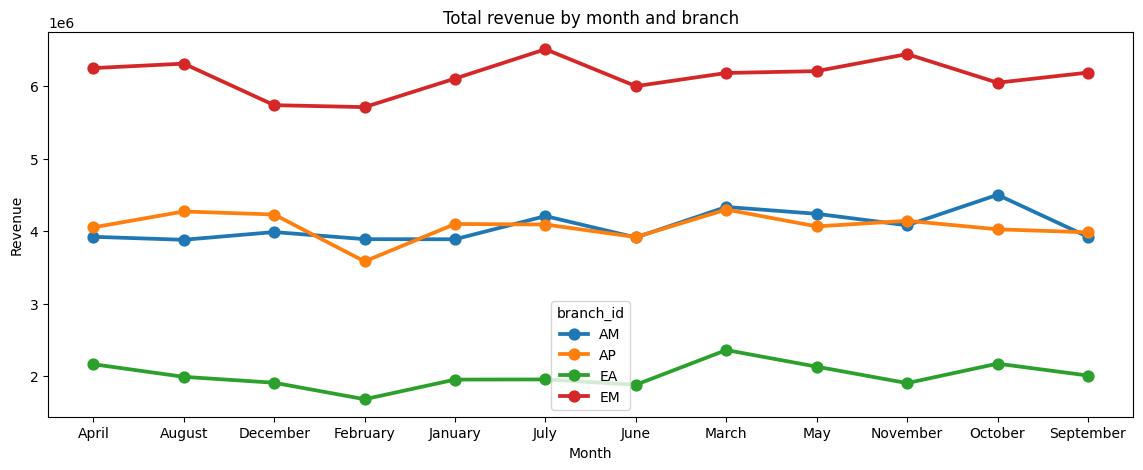

In [84]:
fig,ax= plt.subplots()
fig.set_size_inches(14,5)
sns.pointplot(x=monthAggregated2["Month"], y=monthAggregated2["total_revenue"],hue=monthAggregated2["branch_id"], data=monthAggregated2, join=True,ax=ax)
ax.set(xlabel='Month', ylabel='Revenue',title="Total revenue by month and branch",label='big')
plt.show()

- ##### **Dominant Branch: Branch EM (red line) is the highest-performing branch by a significant margin, with revenue consistently staying between approximately $5.2M and $6.0M. Its peak revenue occurs in July.**

- ##### **Mid-Tier Branches: Branches AM (blue line) and AP (orange line) form the middle tier, with revenues fluctuating between $3.5M and $4.1M. They generally track closely, though AP shows a sharper dip in February.**

- ##### **Lowest Branch: Branch EA (green line) is the lowest-performing branch, with revenue ranging from roughly $1.6M to $2.2M.**

- ##### **Low-Performing Month: February appears to be a universally low-revenue month, as branches EM, AP, and EA all hit their lowest or near-lowest annual points during this time.**

#### **In conclusion, Branch EM is the primary revenue driver, while the mid-tier branches maintain steady performance. Revenue is weakest overall in February.**

----------------------------
- ##### **Total revenue of branch for each day**
----------------------------

In [85]:
dayAggregated2 = pd.DataFrame(df.groupby(["branch_id","Day_name"], sort=True)['total_revenue'].sum()).reset_index()
dayAggregated2

,branch_id,Day_name,total_revenue
0,AM,Friday,6349500
1,AM,Monday,7868100
2,AM,Saturday,6408300
3,AM,Sunday,6736800
4,AM,Thursday,6458400
5,AM,Tuesday,7844400
6,AM,Wednesday,7099500
7,AP,Friday,6977400
8,AP,Monday,7784700
9,AP,Saturday,6312900


C:\Users\RPC\AppData\Local\Temp\ipykernel_2908\4179069911.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=dayAggregated2["Day_name"], y=dayAggregated2["total_revenue"],hue=dayAggregated2["branch_id"], data=dayAggregated2, join=True,ax=ax)


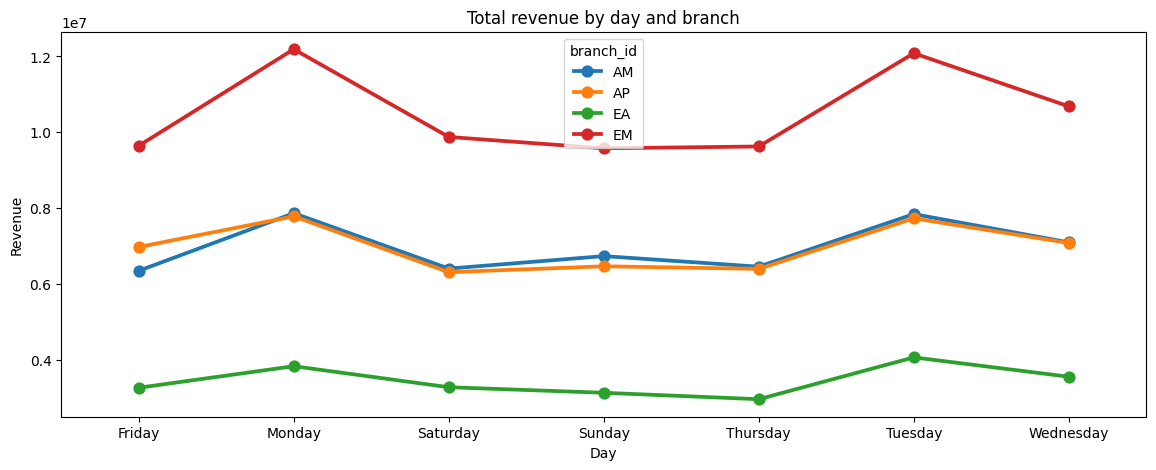

In [86]:
fig,ax= plt.subplots()
fig.set_size_inches(14,5)
sns.pointplot(x=dayAggregated2["Day_name"], y=dayAggregated2["total_revenue"],hue=dayAggregated2["branch_id"], data=dayAggregated2, join=True,ax=ax)
ax.set(xlabel='Day', ylabel='Revenue',title="Total revenue by day and branch",label='big')
plt.show()

- ##### **Start of the Week Spike: All four branches show their highest revenue on Monday and Tuesday, suggesting these are the busiest and most profitable days of the week across the entire organization.**

- ##### **Mid-Week Dip: Revenue generally drops off significantly by Thursday and remains low through the weekend (Saturday and Sunday).**

- ##### **Friday Revenue: Friday shows moderate revenue, lower than Monday/Tuesday but higher than the weekend/Thursday low points.**
------------------------------

- ##### **Total revenue of branch for each period of day**
---------------------------

In [87]:
PeriodsPerDayAggregated2 = pd.DataFrame(df.groupby(["Periods per day","branch_id"], sort=True)["total_revenue"].sum()).reset_index()
PeriodsPerDayAggregated2

,Periods per day,branch_id,total_revenue
0,Afternoon,AM,8096400
1,Afternoon,AP,8015400
2,Afternoon,EA,4005600
3,Afternoon,EM,12470700
4,Evening,AM,5817900
5,Evening,AP,6501300
6,Evening,EA,3069300
7,Evening,EM,8930700
8,Midday/Noon,AM,3815700
9,Midday/Noon,AP,3846900


C:\Users\RPC\AppData\Local\Temp\ipykernel_2908\1036767331.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=PeriodsPerDayAggregated2["Periods per day"], y=PeriodsPerDayAggregated2["total_revenue"],hue=PeriodsPerDayAggregated2["branch_id"], data=PeriodsPerDayAggregated2, join=True,ax=ax)


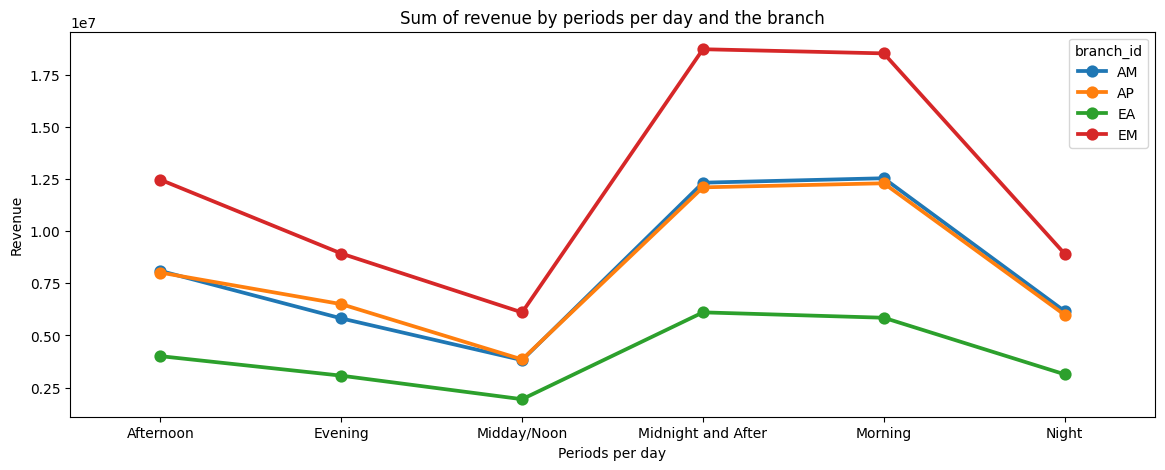

In [88]:
fig,ax= plt.subplots()
fig.set_size_inches(14,5)
sns.pointplot(x=PeriodsPerDayAggregated2["Periods per day"], y=PeriodsPerDayAggregated2["total_revenue"],hue=PeriodsPerDayAggregated2["branch_id"], data=PeriodsPerDayAggregated2, join=True,ax=ax)
ax.set(xlabel='Periods per day', ylabel='Revenue',title="Sum of revenue by periods per day and the branch",label='big')
plt.show()

- ##### **Early Morning (0:00 - 7:00): This period is generally high for all branches, with both EM and AM/AP reaching their peak revenue hours.**

- ##### **Morning Dip (8:00 - 13:00): There is a slight consolidation and a minor drop for most branches, with EA hitting its lowest point at 8:00.**

- ##### **Evening (17:00 - 23:00): Revenue remains very strong for AP and EM during the late hours.**

#### **The analysis highlights that the EM branch is the organization's primary revenue engine, and that the highest collective revenue generation occurs in the early morning hours (around 4:00 to 6:00).**

--------------------------
### ***Revenue analysis by department***
--------------------------
- ##### **Value counts for each department**
--------------------------

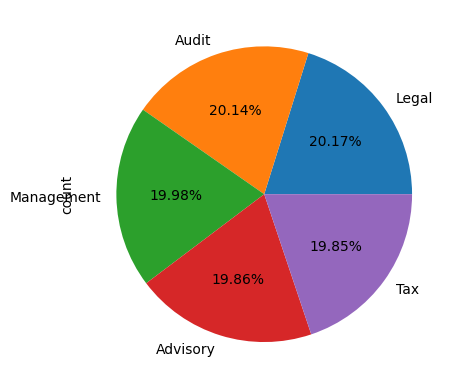

In [89]:
pei(df, 'department')

--------------------------
- ##### **Total revenue for each department**
--------------------------

In [90]:
department_rev_sum = df.groupby('department')['total_revenue'].sum().sort_values(ascending=False)
department_rev_sum

department
Audit         39224100
Management    39221400
Advisory      39024300
Tax           38991000
Legal         38859000
Name: total_revenue, dtype: int64

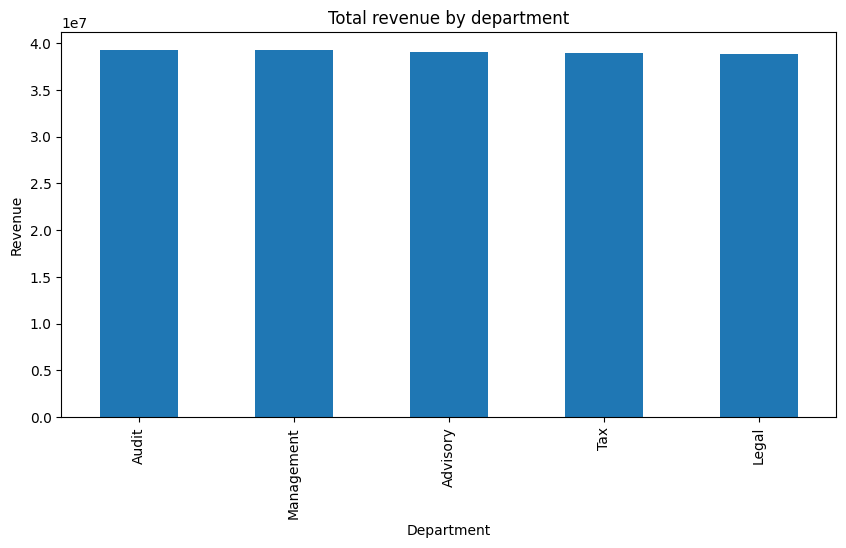

In [91]:
plt.fig,ax= plt.subplots()
plt.fig.set_size_inches(10,5) 
department_rev_sum.plot(kind='bar')
plt.title("Total revenue by department")
plt.xlabel('Department')
plt.ylabel("Revenue")
plt.show()

- ##### **Management department has a highest sum revenue**
- ##### **Legal department a lowest sum revenue**
#### **The values of total revenue ​​are almost similar**

------------------------------
- ##### **Avg revenue of department for each month**
------------------------------

In [92]:
MonthAggregated3 = pd.DataFrame(df.groupby(["Month","department"], sort=True)["total_revenue"].mean()).reset_index()
MonthAggregated3

,Month,department,total_revenue
0,April,Advisory,4219.822109
1,April,Audit,4169.372694
2,April,Legal,4022.066327
3,April,Management,3972.241993
4,April,Tax,4033.799238
5,August,Advisory,3997.898640
6,August,Audit,4044.874715
7,August,Legal,4028.462516
8,August,Management,3940.194884
9,August,Tax,4156.050955


In [93]:
def anovaT(Month):
    Advisory = df[(df['Month'] == Month) & (df['department'] == 'Advisory')]['total_revenue']
    Audit = df[(df['Month'] == Month) & (df['department'] == 'Audit')]['total_revenue']
    Legal = df[(df['Month'] == Month) & (df['department'] == 'Legal')]['total_revenue']
    Management = df[(df['Month'] == Month) & (df['department'] == 'Management')]['total_revenue']
    Tax = df[(df['Month'] == Month) & (df['department'] == 'Tax')]['total_revenue']

    anova_test = f_oneway(Advisory, Audit, Legal, Management,Tax)
    if anova_test.pvalue < 0.05:
        return "The difference is statistically significant."
    else :
        return "The difference is not statistically significant."

In [94]:
for m in df['Month'].unique():
    print(m)
    print(anovaT(m))

August
The difference is not statistically significant.
December
The difference is statistically significant.
October
The difference is not statistically significant.
November
The difference is not statistically significant.
February
The difference is not statistically significant.
June
The difference is not statistically significant.
March
The difference is not statistically significant.
January
The difference is not statistically significant.
April
The difference is not statistically significant.
September
The difference is not statistically significant.
July
The difference is statistically significant.
May
The difference is not statistically significant.


C:\Users\RPC\AppData\Local\Temp\ipykernel_2908\4070729185.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=MonthAggregated3["Month"], y=MonthAggregated3["total_revenue"],hue=MonthAggregated3["department"], data=MonthAggregated3, join=True,ax=ax)


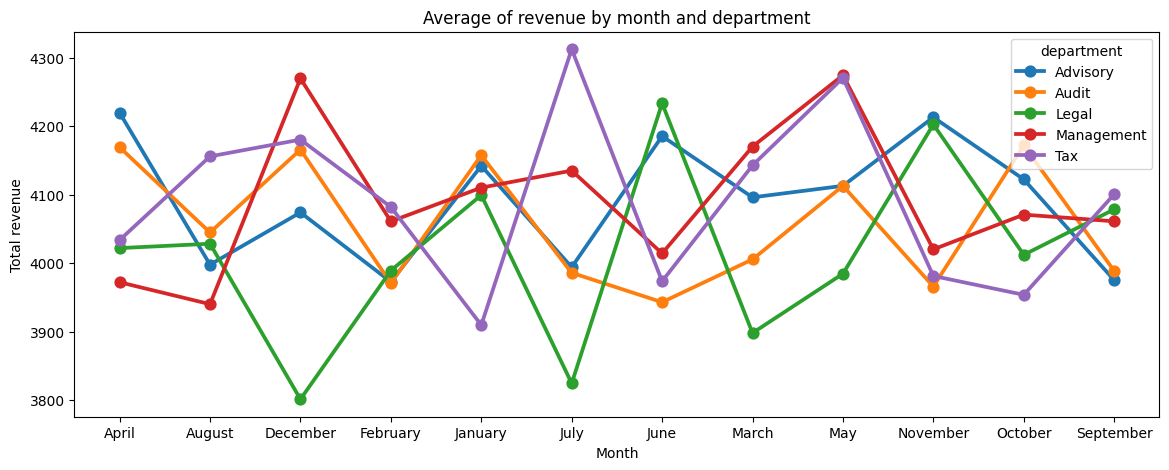

In [95]:
fig,ax= plt.subplots()
fig.set_size_inches(14,5)
sns.pointplot(x=MonthAggregated3["Month"], y=MonthAggregated3["total_revenue"],hue=MonthAggregated3["department"], data=MonthAggregated3, join=True,ax=ax)
ax.set(xlabel='Month', ylabel='Total revenue',title="Average of revenue by month and department",label='big')
plt.show()

- ##### **May is the month with the highest average revenue, driven by the Tax department's peak.**

- ##### **December is a month of high contrast: Management peaks, while Legal hits its absolute lowest point.**

- ##### **The ordering of the Month on the x-axis is not chronological (e.g., April, August, December, February, January...), which makes analyzing a continuous seasonal trend difficult.**

------------------------------
- ##### **Avg revenue of department for each day**
------------------------------

In [96]:
dayAggregated2 = pd.DataFrame(df.groupby(["Day_name","department"], sort=True)["total_revenue"].mean()).reset_index()
dayAggregated2

,Day_name,department,total_revenue
0,Friday,Advisory,4154.086538
1,Friday,Audit,4066.276347
2,Friday,Legal,4071.656535
3,Friday,Management,4116.937355
4,Friday,Tax,4077.111287
5,Monday,Advisory,4026.724138
6,Monday,Audit,4112.792907
7,Monday,Legal,4051.558442
8,Monday,Management,4142.783505
9,Monday,Tax,4170.097087


In [97]:
def anovaT2(day):
    Advisory = df[(df['Day_name'] == day) & (df['department'] == 'Advisory')]['total_revenue']
    Audit = df[(df['Day_name'] == day) & (df['department'] == 'Audit')]['total_revenue']
    Legal = df[(df['Day_name'] == day) & (df['department'] == 'Legal')]['total_revenue']
    Management = df[(df['Day_name'] == day) & (df['department'] == 'Management')]['total_revenue']
    Tax = df[(df['Day_name'] == day) & (df['department'] == 'Tax')]['total_revenue']

    anova_test = f_oneway(Advisory, Audit, Legal, Management,Tax)
    if anova_test.pvalue < 0.05:
        return "The difference is statistically significant."
    else :
        return "The difference is not statistically significant."

In [98]:
for d in df['Day_name'].unique():
    print(d)
    print(anovaT2(d))

Saturday
The difference is not statistically significant.
Wednesday
The difference is not statistically significant.
Sunday
The difference is not statistically significant.
Monday
The difference is not statistically significant.
Friday
The difference is not statistically significant.
Tuesday
The difference is not statistically significant.
Thursday
The difference is not statistically significant.


C:\Users\RPC\AppData\Local\Temp\ipykernel_2908\2916261459.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=dayAggregated2["Day_name"], y=dayAggregated2["total_revenue"],hue=dayAggregated2["department"], data=dayAggregated2, join=True,ax=ax)


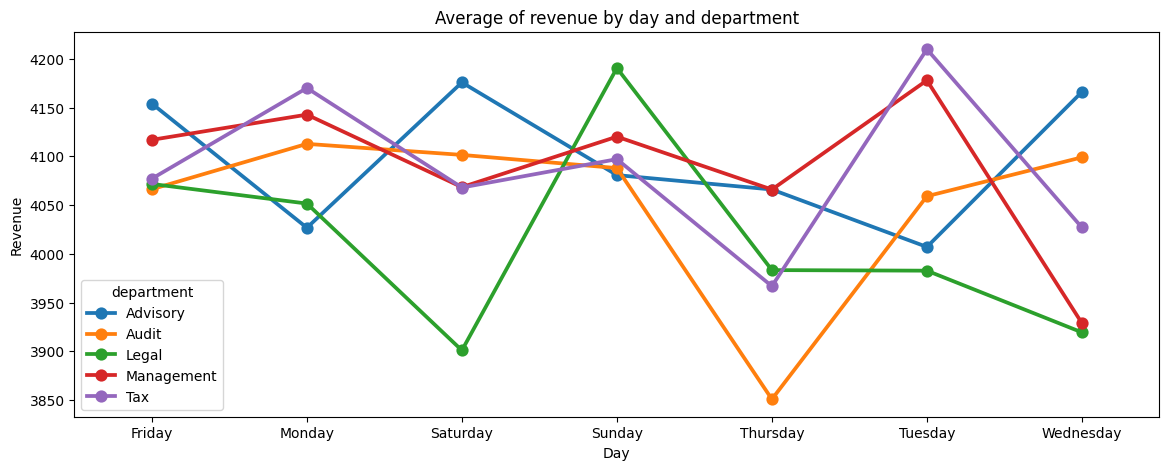

In [99]:
fig,ax= plt.subplots()
fig.set_size_inches(14,5)
sns.pointplot(x=dayAggregated2["Day_name"], y=dayAggregated2["total_revenue"],hue=dayAggregated2["department"], data=dayAggregated2, join=True,ax=ax)
ax.set(xlabel='Day', ylabel='Revenue',title="Average of revenue by day and department",label='big')
plt.show()

- ##### **Saturday is a strong day, with Advisory, Audit, and Tax all performing well, though Legal is at one of its lowest points.**

- ##### **Tuesday is a peak day for Management and another high point for Tax.**

- ##### **Sunday is an outlier, being the absolute best day for Legal, yet one of the weakest days for Advisory and Tax.**

- ##### **Thursday is a generally weak day, as both Audit and Tax hit their lowest points here.**

------------------------------
- ##### **Avg revenue of department for each period of day**
------------------------------

In [100]:
PeriodsperdayAggregated2 = pd.DataFrame(df.groupby(["Periods per day","department"], sort=True)["total_revenue"].mean()).reset_index()
PeriodsperdayAggregated2

,Periods per day,department,total_revenue
0,Afternoon,Advisory,4098.289554
1,Afternoon,Audit,4037.192755
2,Afternoon,Legal,4057.238852
3,Afternoon,Management,3942.673993
4,Afternoon,Tax,4158.969466
5,Evening,Advisory,4008.647260
6,Evening,Audit,4068.509615
7,Evening,Legal,4037.785016
8,Evening,Management,4126.400679
9,Evening,Tax,4068.927039


In [101]:
def anovaT3(Periods):
    Advisory = df[(df['Periods per day'] == Periods) & (df['department'] == 'Advisory')]['total_revenue']
    Audit = df[(df['Periods per day'] == Periods) & (df['department'] == 'Audit')]['total_revenue']
    Legal = df[(df['Periods per day'] == Periods) & (df['department'] == 'Legal')]['total_revenue']
    Management = df[(df['Periods per day'] == Periods) & (df['department'] == 'Management')]['total_revenue']
    Tax = df[(df['Periods per day'] == Periods) & (df['department'] == 'Tax')]['total_revenue']

    anova_test = f_oneway(Advisory, Audit, Legal, Management, Tax)
    if anova_test.pvalue < 0.05:
        print('Periods :', Periods)
        print("The difference is statistically significant.")
    else :
        return None

In [102]:
for i in range(0, PeriodsperdayAggregated2.shape[0] + 1):
    anovaT3(i)

C:\Users\RPC\AppData\Local\Temp\ipykernel_2908\4039062543.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  anova_test = f_oneway(Advisory, Audit, Legal, Management, Tax)


C:\Users\RPC\AppData\Local\Temp\ipykernel_2908\1096887025.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=PeriodsperdayAggregated2["Periods per day"], y=PeriodsperdayAggregated2["total_revenue"],hue=PeriodsperdayAggregated2["department"], data=PeriodsperdayAggregated2, join=True,ax=ax)


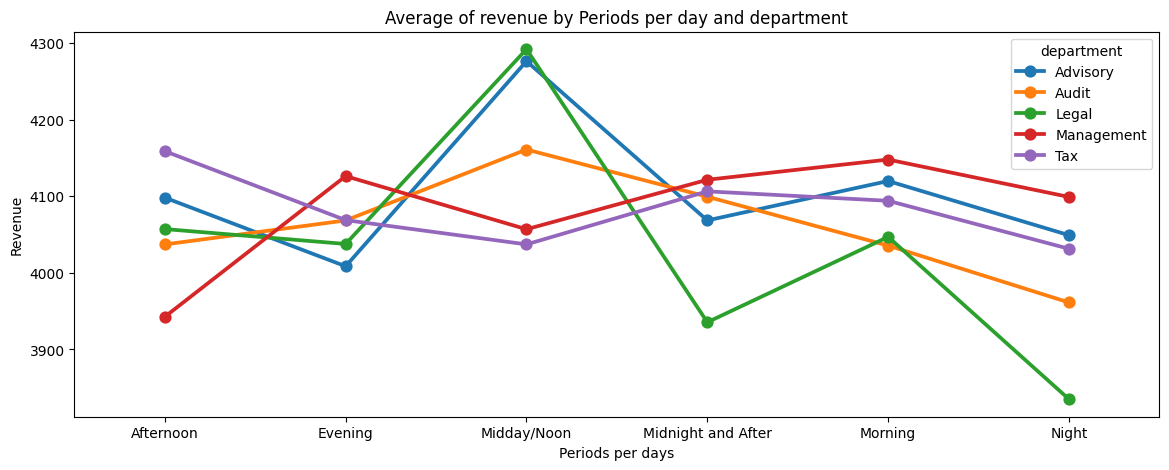

In [103]:
fig,ax= plt.subplots()
fig.set_size_inches(14,5)
sns.pointplot(x=PeriodsperdayAggregated2["Periods per day"], y=PeriodsperdayAggregated2["total_revenue"],hue=PeriodsperdayAggregated2["department"], data=PeriodsperdayAggregated2, join=True,ax=ax)
ax.set(xlabel='Periods per days', ylabel='Revenue',title="Average of revenue by Periods per day and department",label='big')
plt.show()

#### **Advisory (Blue Line):**

- ##### **Peak Hours:** Experiences its highest revenue at 1:00 (over $4,400) and another major peak at 13:00 (also over $4,400).

- ##### **Low Points:** Drops notably around 4:00 and 15:00.

#### **Audit (Orange Line):**

- ##### **Peak Hours:** Relatively consistent high performance in the early hours (around 1:00).

- ##### **Low Points:** Shows significant dips at 5:00, 9:00, and 15:00, generally fluctuating between $3,800 and $4,200.

#### **Legal (Green Line):**

- ##### **Peak Hours:** Starts the day with its lowest point at 0:00 (around $3,550) but recovers quickly, peaking around 7:00 and again at 12:00 and 20:00.

- ##### **Low Points:** Has its lowest points at 0:00, 9:00, and 16:00 (around $3,700).

#### **Management (Red Line):**

- ##### **Peak Hours:** Tends to peak during standard working hours and late evening, specifically at 4:00, 7:00, and a major peak at 22:00 (highest overall revenue point, close to $4,400).

- ##### **Low Points:** Hits its lowest points around 16:00 (around $3,700) and at 23:00.

#### **Tax (Purple Line):**

- ##### **Peak Hours:** Displays strong revenue in the morning, peaking at 9:00 (around $4,400).

- ##### **Low Points:** Has its most significant dips at 8:00 and 17:00, occasionally dipping below $3,800.

------------------------------------
------------------------------------


# <center><strong>Observation & Interpretation</strong></center>
--------------------------------------------
##### **The analysis shows that Branch EM clearly leads in total revenue across months, days of the week, and periods of the day, making it the primary driver of the company’s financial performance. The results also reveal a consistent weekly pattern, with revenue peaking at the beginning of the week and gradually declining toward the end, especially on Thursday, which records the weakest performance. In terms of seasonality, revenue remains relatively stable throughout the year, with the exception of May, which shows the highest average revenue. Across departments, the Tax, Audit, and Advisory departments demonstrate similar performance levels with no statistically significant differences, indicating stable and balanced demand for the company’s services. Overall, the company exhibits strong and steady financial performance with clear weekly trends and minimal seasonal fluctuations.**

---------------------------------------

In [1]:
!jupyter nbconvert --to html "services analysis_project.ipynb"

[NbConvertApp] Converting notebook services analysis_project.ipynb to html
C:\Users\RPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
[NbConvertApp] WARNING | Alternative text is missing on 38 image(s).
[NbConvertApp] Writing 3379950 bytes to services analysis_project.html
